In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split, TunedThresholdClassifierCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [20]:
heart_df = pd.read_csv("../data/heart_2020_cleaned.csv") 
heart_df['HeartDisease'] = heart_df['HeartDisease'].map({'No':0,'Yes':1})
heart_df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,0,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,0,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,0,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,0,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,1,27.41,Yes,No,No,7,0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6,Yes,No,No
319791,0,29.84,Yes,No,No,0,0,No,Male,35-39,Hispanic,No,Yes,Very good,5,Yes,No,No
319792,0,24.24,No,No,No,0,0,No,Female,45-49,Hispanic,No,Yes,Good,6,No,No,No
319793,0,32.81,No,No,No,0,0,No,Female,25-29,Hispanic,No,No,Good,12,No,No,No


In [9]:
# from ydata_profiling import ProfileReport
# ProfileReport(heart_df)

# Train-Test split

In [21]:
from sklearn.model_selection import train_test_split

X = heart_df.drop('HeartDisease', axis=1)
y = heart_df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessor with one-hot encoding

In [22]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer

X_num = X_train.select_dtypes(include='number')
X_cat = X_train.select_dtypes(exclude='number')

# Categorical columns
cat_cols = X_cat.columns

# Numeric columns (all others)
num_cols = X_num.columns

# Numeric pipeline
num_pipe = Pipeline([
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine into preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


# Preprocessor with both one-hot & ordinal encoding

In [23]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


# -----------------------------
# 1. ORDINAL COLUMNS & CATEGORIES
# -----------------------------

ordinal_cols = ["AgeCategory", "GenHealth", "Diabetic"]

ordinal_categories = [

    # AgeCategory order
    ["18-24", "25-29", "30-34", "35-39", "40-44", "45-49",
     "50-54", "55-59", "60-64", "65-69", "70-74", "75-79", "80 or older"],

    # GenHealth order
    ["Poor", "Fair", "Good", "Very good", "Excellent"],

    # Diabetic order
    ["No", "No, borderline diabetes", "Yes", "Yes (during pregnancy)"]
]


# -----------------------------
# 2. Nominal categorical columns
# -----------------------------

nominal_cols = [
    'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex',
    'Race', 'PhysicalActivity', 'Asthma',
    'KidneyDisease', 'SkinCancer'
]


# -----------------------------
# 3. Numeric columns
# -----------------------------

num_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']


# -----------------------------
# 4. PIPELINES
# -----------------------------

# Numeric pipeline
num_pipe = Pipeline([
    ("scaler", StandardScaler())
])

# Ordinal pipeline
ordinal_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(categories=ordinal_categories))
])

# Nominal pipeline
nominal_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


# -----------------------------
# 5. COMBINED PREPROCESSOR
# -----------------------------

preprocessor_ord = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("ord", ordinal_pipe, ordinal_cols),
    ("nom", nominal_pipe, nominal_cols)
])

preprocessor_ord

,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


# Function to test with different models

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, recall_score, confusion_matrix
from sklearn.feature_selection import SelectFromModel

models_score = []

def test_model(model, X_train, X_test, y_train, y_test, threshold=0.5):

    selector = SelectFromModel(
        RandomForestClassifier(n_estimators=200, random_state=42),
        threshold="median"      # keep features above median importance
    )

    pipe = Pipeline([
        ("prep", preprocessor),
        ("select", selector),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
      # ----------- NEW PART: prediction probability + threshold -----------
    probs = pipe.predict_proba(X_test)[:, 1]      # probability of class 1
    preds = (probs >= threshold).astype(int)      # convert to 0/1 based on threshold
    # -------------------------------------------------------------------

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    f2 = ((1 + 2**2) * prec * rec) / (2**2 * prec + rec)
    
    print("\n============================")
    print(model.__class__.__name__)
    print("============================")

    
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    print("Confusion Matrix:")
    print(f"TP={tp}, FN={fn}, FP={fp}, TN={tn}")
    print("Recall =", recall_score(y_test, preds))

    models_score.append({
            "Model": model.__class__.__name__,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1,
            "F2": f2
        })
    results_df = pd.DataFrame(models_score).sort_values(by="Recall", ascending=False).reset_index(drop=True)
    return results_df

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, recall_score, confusion_matrix
from sklearn.feature_selection import SelectFromModel

models_score = []

def evaluate_model(model_name,  probs, y_test, threshold=0.5):
    preds = (probs >= threshold).astype(int)      # convert to 0/1 based on threshold
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    f2 = ((1 + 2**2) * prec * rec) / (2**2 * prec + rec)
    
    print("\n============================")
    print(model_name)
    print("============================")

    
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    print("Confusion Matrix:")
    print(f"TP={tp}, FN={fn}, FP={fp}, TN={tn}")
    print("Recall =", recall_score(y_test, preds))

    models_score.append({
            "Model": model_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1,
            "F2": f2
        })
    results_df = pd.DataFrame(models_score).sort_values(by="Recall", ascending=False).reset_index(drop=True)
    return results_df

# Logistic Regression

## Initial fit

In [14]:
from sklearn.linear_model import LogisticRegression
selector = SelectFromModel(
    RandomForestClassifier(n_estimators=200, random_state=42),
    threshold="median"      # keep features above median importance
)
model = LogisticRegression(
    C=10,                    # less regularization
    penalty='l2',
    solver='saga',
    class_weight='balanced',
    max_iter=1000,           # may need fewer iterations
    random_state=42
)

pipe = Pipeline([
    ("prep", preprocessor_ord),
    ("select", selector),
    ("model", model)
])

pipe.fit(X_train, y_train)
probs = pipe.predict_proba(X_test)[:, 1]      # probability of class 1

evaluate_model(model.__class__.__name__, probs, y_test)


LogisticRegression
Confusion Matrix:
TP=4273, FN=1319, FP=15788, TN=42579
Recall = 0.7641273247496424


,Model,Accuracy,Precision,Recall,F1 Score,F2
0,DecisionTreeClassifier,0.654701,0.171074,0.766989,0.279751,0.452054
1,LogisticRegression,0.732532,0.213000,0.764127,0.333138,0.503547


## Randomized search

In [ ]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from scipy.stats import randint, uniform

pipe = Pipeline([
    ("prep", preprocessor_ord),
    ("select", selector),
    ("model", model)
])

# Parameter distributions
param_dist = {
    # Preprocessing
    'prep__nom__onehot__drop': [None, 'first'],
    'prep__nom__onehot__sparse_output': [True, False],
    
    # Feature selection
    'select__estimator__n_estimators': randint(100, 500),
    'select__threshold': ['0.1*mean', 'mean', 'median'],

    # Logistic Regression
    'model__C': uniform(0.1, 50),
    'model__solver': ['saga'],  # saga works with l1/l2 + large data
    'model__penalty': ['l2', 'l1'],
    'model__class_weight': ['balanced', None]
}

# Stratified CV for imbalanced data
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Randomized search
rand_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=10,          # number of random combinations
    scoring='roc_auc',  # good for imbalanced data
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit
rand_search.fit(X_train, y_train)

# Best results
print(f"Best params: {rand_search.best_params_}")
print(f"Best ROC-AUC: {rand_search.best_score_:.4f}")

# Predict probabilities
probs = rand_search.predict_proba(X_test)[:, 1]
evaluate_model(rand_search.best_estimator_.named_steps['model'].__class__.__name__, probs, y_test)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


Results:

{'model__C': np.float64(18.827005942368125),
 'model__class_weight': 'balanced',
 'model__penalty': 'l2',
 'model__solver': 'saga',
 'prep__nom__onehot__drop': None,
 'prep__nom__onehot__sparse_output': False,
 'select__estimator__n_estimators': 288,
 'select__threshold': '0.1*mean'}

## Grid search --> not done yet

## Tune threshold

In [53]:
from sklearn.linear_model import LogisticRegression
selector = SelectFromModel(
    RandomForestClassifier(n_estimators=288, random_state=42),
    threshold="0.1*mean"      # keep features above median importance
)

model = LogisticRegression(
    C=18.8,                    # less regularization
    penalty='l2',
    solver='saga',
    class_weight='balanced',
    max_iter=1000,           # may need fewer iterations
    random_state=42
)

# Use same pipeline structure
pipe = Pipeline([
    ("prep", preprocessor_ord),
    ("select", selector),
    ("model", model)
])

pipe.fit(X_train, y_train)
probs = pipe.predict_proba(X_test)[:, 1]
evaluate_model(model.__class__.__name__, probs, y_test)


LogisticRegression
Confusion Matrix:
TP=4349, FN=1243, FP=14737, TN=43630
Recall = 0.7777181688125894


,Model,Accuracy,Precision,Recall,F1 Score,F2
0,GradientBoostingClassifier,0.506387,0.145144,0.950107,0.251819,0.450460
1,LogisticRegression,0.750152,0.227863,0.777718,0.352460,0.524557
2,DecisionTreeClassifier,0.759471,0.228753,0.738376,0.349294,0.510787
3,RandomForestClassifier,0.757329,0.224974,0.726216,0.343527,0.502363
4,[DecisionTreeClassifier 0.1442],0.822042,0.276206,0.638948,0.385687,0.506033
5,GradientBoostingClassifier,0.914054,0.572298,0.067239,0.120339,0.081650
6,GradientBoostingClassifier,0.914054,0.572298,0.067239,0.120339,0.081650
7,DecisionTreeClassifier,0.914054,0.572298,0.067239,0.120339,0.081650


In [54]:
tuned_model = TunedThresholdClassifierCV(
    estimator=pipe,#rfc_search.best_estimator_,
    scoring=combined_scorer,
    store_cv_results=True  # necessary to inspect all results
)

_ = tuned_model.fit(X_train, y_train)
tuned_model.best_threshold_ 
evaluate_model([model.__class__.__name__ + " " + str(round(tuned_model.best_threshold_,4) )],
                probs, y_test, tuned_model.best_threshold_ )

MemoryError: Unable to allocate 1.56 MiB for an array with shape (204668,) and data type int64

In [55]:
_ = tuned_model.fit(X_train, y_train)

MemoryError: Unable to allocate 1.56 MiB for an array with shape (204668,) and data type int64

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, class_weight="balanced")
test_model(dt, X_train, X_test, y_train, y_test, threshold=0.19)


DecisionTreeClassifier
Confusion Matrix:
TP=5357, FN=235, FP=35233, TN=23134
Recall = 0.9579756795422032


,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.419878,0.127659,0.966023,0.225516
1,DecisionTreeClassifier,0.445457,0.131978,0.957976,0.231995


## First run

In [9]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=10,                    # Prevent overfitting on 320K samples
    min_samples_split=1000,          # ~0.3% of data (320K/320)
    min_samples_leaf=500,            # ~0.15% of data
    class_weight='balanced',         # Handle 8% imbalance
    random_state=42,
    criterion='gini',                # Start with gini (faster)
    max_features='sqrt',             # Adds randomness, reduces overfitting
    min_impurity_decrease=0.0001     # Prune small improvements
)

# Use same pipeline structure
pipe = Pipeline([
    ("prep", preprocessor),
    ("model", model)  # Remove feature selector - trees handle this
])

pipe.fit(X_train, y_train)
probs = pipe.predict_proba(X_test)[:, 1]
evaluate_model(model.__class__.__name__, probs, y_test)


DecisionTreeClassifier
Confusion Matrix:
TP=4289, FN=1303, FP=20782, TN=37585
Recall = 0.7669885550786838


,Model,Accuracy,Precision,Recall,F1 Score,F2
0,DecisionTreeClassifier,0.654701,0.171074,0.766989,0.279751,0.452054


## Randomized Search

In [30]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# Define distributions for random sampling
param_distributions = {
    'model__max_depth': randint(8, 25),                    # Sample from 8-24
    'model__min_samples_split': randint(500, 3000),        # Sample from 500-2999
    'model__min_samples_leaf': randint(250, 1500),         # Sample from 250-1499
    'model__criterion': ['gini', 'entropy'],
    'model__max_features': ['sqrt', 'log2', None],
    'model__class_weight': ['balanced', {0: 1, 1: 12}],
    'model__min_impurity_decrease': uniform(0, 0.002)      # Sample from 0-0.002
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # Reduced to 3 folds

random_search = RandomizedSearchCV(
    pipe,
    param_distributions,
    n_iter=30,              # Try 30 random combinations (vs 1000+ in full grid)
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)
print(f"Best params: {random_search.best_params_}")
print(f"Best ROC-AUC: {random_search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 8, 'model__max_features': None, 'model__min_impurity_decrease': np.float64(0.00014808930346818072), 'model__min_samples_leaf': 480, 'model__min_samples_split': 2588}
Best ROC-AUC: 0.8273


In [33]:
probs = random_search.predict_proba(X_test)[:, 1]
evaluate_model(model.__class__.__name__, probs, y_test)


DecisionTreeClassifier
Confusion Matrix:
TP=4411, FN=1181, FP=16327, TN=42040
Recall = 0.7888054363376252


,Model,Accuracy,Precision,Recall,F1 Score,F2
0,DecisionTreeClassifier,0.726262,0.212701,0.788805,0.335055,0.511646
1,DecisionTreeClassifier,0.686330,0.188361,0.782010,0.303596,0.479664
2,DecisionTreeClassifier,0.686330,0.188361,0.782010,0.303596,0.479664
3,LogisticRegression,0.732532,0.213000,0.764127,0.333138,0.503547
4,LogisticRegression,0.732532,0.213000,0.764127,0.333138,0.503547


## Grid search around best regions

In [ ]:
param_grid = {
    'model__max_depth': [10, 12],
    'model__min_samples_split': [2500],
    'model__min_samples_leaf': [350, 400],
    'model__criterion': ['gini'],
    'model__max_features': [ None],
    'model__class_weight': ['balanced'],
    'model__min_impurity_decrease': [ 0.000001, 0.00001]
}

from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__class_weight': ['balanced'], 'model__criterion': ['gini'], 'model__max_depth': [6, 8, ...], 'model__max_features': [None], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('ord', ...), ...]"


In [35]:
probs = grid.predict_proba(X_test)[:, 1]
evaluate_model(model.__class__.__name__, probs, y_test)


DecisionTreeClassifier
Confusion Matrix:
TP=4432, FN=1160, FP=16548, TN=41819
Recall = 0.7925608011444921


,Model,Accuracy,Precision,Recall,F1 Score,F2
0,DecisionTreeClassifier,0.723135,0.211249,0.792561,0.333584,0.511212
1,DecisionTreeClassifier,0.726262,0.212701,0.788805,0.335055,0.511646
2,DecisionTreeClassifier,0.686330,0.188361,0.782010,0.303596,0.479664
3,DecisionTreeClassifier,0.686330,0.188361,0.782010,0.303596,0.479664
4,LogisticRegression,0.732532,0.213000,0.764127,0.333138,0.503547
5,LogisticRegression,0.732532,0.213000,0.764127,0.333138,0.503547


## Tune Threshold

In [39]:
model = DecisionTreeClassifier(
    max_depth=10,                    # Prevent overfitting on 320K samples
    min_samples_split=2500,          # ~0.3% of data (320K/320)
    min_samples_leaf=400,            # ~0.15% of data
    class_weight='balanced',         # Handle 8% imbalance
    random_state=42,
    criterion='gini',                # Start with gini (faster)
    max_features=None,             # Adds randomness, reduces overfitting
    min_impurity_decrease=0.00001     # Prune small improvements
)

# Use same pipeline structure
dt_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", model)  # Remove feature selector - trees handle this
])

pipe.fit(X_train, y_train)
probs = pipe.predict_proba(X_test)[:, 1]
evaluate_model(model.__class__.__name__, probs, y_test)


DecisionTreeClassifier
Confusion Matrix:
TP=376, FN=5216, FP=281, TN=58086
Recall = 0.06723891273247497


,Model,Accuracy,Precision,Recall,F1 Score,F2
0,GradientBoostingClassifier,0.506387,0.145144,0.950107,0.251819,0.45046
1,GradientBoostingClassifier,0.914054,0.572298,0.067239,0.120339,0.08165
2,GradientBoostingClassifier,0.914054,0.572298,0.067239,0.120339,0.08165
3,DecisionTreeClassifier,0.914054,0.572298,0.067239,0.120339,0.08165


In [ ]:
dt_tuned_model = TunedThresholdClassifierCV(
    estimator=dt_pipe,#rfc_search.best_estimator_,
    scoring=combined_scorer,
    store_cv_results=True  # necessary to inspect all results
)

_ = dt_tuned_model.fit(X_train, y_train)
dt_tuned_model.best_threshold_ 
evaluate_model([model.__class__.__name__ + " " + str(round(dt_tuned_model.best_threshold_,4) )],
                probs, y_test, dt_tuned_model.best_threshold_ )

AttributeError: 'TunedThresholdClassifierCV' object has no attribute 'best_threshold_'

In [46]:
evaluate_model([model.__class__.__name__ + " " + str(round(dt_tuned_model.best_threshold_,4) )],
                probs, y_test, dt_tuned_model.best_threshold_ )


['DecisionTreeClassifier 0.1442']
Confusion Matrix:
TP=3573, FN=2019, FP=9363, TN=49004
Recall = 0.6389484978540773


,Model,Accuracy,Precision,Recall,F1 Score,F2
0,GradientBoostingClassifier,0.506387,0.145144,0.950107,0.251819,0.450460
1,[DecisionTreeClassifier 0.1442],0.822042,0.276206,0.638948,0.385687,0.506033
2,GradientBoostingClassifier,0.914054,0.572298,0.067239,0.120339,0.081650
3,GradientBoostingClassifier,0.914054,0.572298,0.067239,0.120339,0.081650
4,DecisionTreeClassifier,0.914054,0.572298,0.067239,0.120339,0.081650


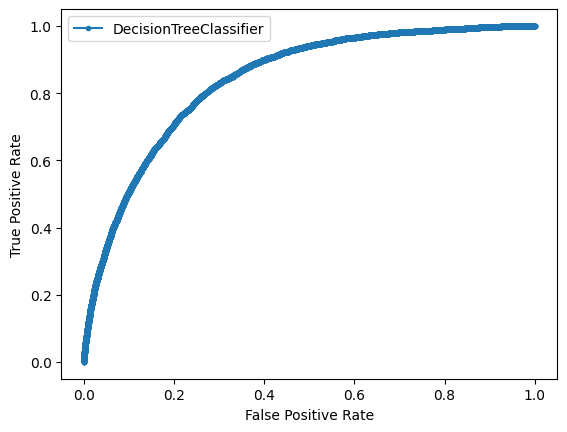

In [47]:
# calculate roc curves
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
%matplotlib inline

probs = pipe.predict_proba(X_test)[:, 1]  # probability for class 1
fpr, tpr, thresholds = roc_curve(y_test, probs)
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.', label=model.__class__.__name__)
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()

In [48]:
# 1) Get feature names after preprocessing
feature_names = pipe.named_steps["prep"].get_feature_names_out()

# 2) Get importances from the decision tree
importances = pipe.named_steps["model"].feature_importances_

# 3) Put into a DataFrame and sort
fi = pd.DataFrame(
    {"feature": feature_names, "importance": importances}
).sort_values("importance", ascending=False)

print(fi.head(20))   # top 20 features


                         feature  importance
9                cat__Stroke_Yes    0.113341
26  cat__AgeCategory_80 or older    0.078693
42           cat__GenHealth_Poor    0.064632
35             cat__Diabetic_Yes    0.061974
11          cat__DiffWalking_Yes    0.057426
1            num__PhysicalHealth    0.054889
10           cat__DiffWalking_No    0.049345
33              cat__Diabetic_No    0.042952
25        cat__AgeCategory_75-79    0.042853
8                 cat__Stroke_No    0.040968
40           cat__GenHealth_Fair    0.039781
13                 cat__Sex_Male    0.034667
24        cat__AgeCategory_70-74    0.033225
47        cat__KidneyDisease_Yes    0.032262
12               cat__Sex_Female    0.030598
43      cat__GenHealth_Very good    0.027644
46         cat__KidneyDisease_No    0.026461
39      cat__GenHealth_Excellent    0.023676
23        cat__AgeCategory_65-69    0.015534
41           cat__GenHealth_Good    0.015432


# Random Forest

## Do later

In [49]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)
rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", rf)  # No feature selector - boosting handles this
])
rf_pipe.fit(X_train, y_train)
# Evaluate
probs = rf_pipe.predict_proba(X_test)[:, 1]
evaluate_model(model.__class__.__name__, probs, y_test)
 #, threshold=0.19


DecisionTreeClassifier
Confusion Matrix:
TP=4129, FN=1463, FP=13921, TN=44446
Recall = 0.7383762517882689

RandomForestClassifier
Confusion Matrix:
TP=4061, FN=1531, FP=13990, TN=44377
Recall = 0.7262160228898427


,Model,Accuracy,Precision,Recall,F1 Score,F2
0,GradientBoostingClassifier,0.506387,0.145144,0.950107,0.251819,0.450460
1,DecisionTreeClassifier,0.759471,0.228753,0.738376,0.349294,0.510787
2,RandomForestClassifier,0.757329,0.224974,0.726216,0.343527,0.502363
3,[DecisionTreeClassifier 0.1442],0.822042,0.276206,0.638948,0.385687,0.506033
4,GradientBoostingClassifier,0.914054,0.572298,0.067239,0.120339,0.081650
5,GradientBoostingClassifier,0.914054,0.572298,0.067239,0.120339,0.081650
6,DecisionTreeClassifier,0.914054,0.572298,0.067239,0.120339,0.081650


In [ ]:
threshold=0.19
evaluate_model([model.__class__.__name__ + " " + threshold], probs, y_test, threshold)

# Gradient boost

## Initial Fit

In [81]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
test_model(gb, X_train, X_test, y_train, y_test,threshold=0.19)


GradientBoostingClassifier
Confusion Matrix:
TP=2836, FN=2756, FP=6503, TN=51864
Recall = 0.5071530758226037


,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.419878,0.127659,0.966023,0.225516
1,RandomForestClassifier,0.453838,0.134073,0.961195,0.235322
2,DecisionTreeClassifier,0.445457,0.131978,0.957976,0.231995
3,GradientBoostingClassifier,0.855235,0.303673,0.507153,0.379881


In [ ]:
model = GradientBoostingClassifier(
    n_estimators=200,                # Moderate number of trees
    learning_rate=0.1,               # Standard learning rate
    max_depth=5,                     # Shallow trees (typical for boosting)
    min_samples_split=1000,
    min_samples_leaf=500,
    subsample=0.8,                   # Use 80% of data per tree (faster + regularization)
    max_features='sqrt',
    random_state=42,
    verbose=2                        # Show progress
)
pipe = Pipeline([
    ("prep", preprocessor),
    ("model", model)  # No feature selector - boosting handles this
])
pipe.fit(X_train, y_train)
# Evaluate
probs = pipe.predict_proba(X_test)[:, 1]
evaluate_model(model.__class__.__name__, probs, y_test)

In [39]:
probs = pipe.predict_proba(X_test)[:, 1]
evaluate_model(model.__class__.__name__, probs, y_test)


GradientBoostingClassifier
Confusion Matrix:
TP=491, FN=5101, FP=383, TN=57984
Recall = 0.08780400572246065


,Model,Accuracy,Precision,Recall,F1 Score,F2
0,DecisionTreeClassifier,0.723135,0.211249,0.792561,0.333584,0.511212
1,DecisionTreeClassifier,0.726262,0.212701,0.788805,0.335055,0.511646
2,DecisionTreeClassifier,0.686330,0.188361,0.782010,0.303596,0.479664
3,DecisionTreeClassifier,0.686330,0.188361,0.782010,0.303596,0.479664
4,LogisticRegression,0.732532,0.213000,0.764127,0.333138,0.503547
5,LogisticRegression,0.732532,0.213000,0.764127,0.333138,0.503547
6,GradientBoostingClassifier,0.914258,0.561785,0.087804,0.151871,0.105628


## Randomized search

In [40]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# Gradient Boosting model
model = GradientBoostingClassifier(
    random_state=42,
    verbose=0
)

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", model)  # No feature selector - boosting handles this
])

# Parameter distributions for random search
param_distributions = {
    'model__n_estimators': randint(100, 500),              # Number of trees
    'model__learning_rate': uniform(0.01, 0.29),           # 0.01 to 0.3
    'model__max_depth': randint(3, 10),                    # Shallow trees for boosting
    'model__min_samples_split': randint(500, 3000),
    'model__min_samples_leaf': randint(250, 1500),
    'model__subsample': uniform(0.6, 0.4),                 # 0.6 to 1.0
    'model__max_features': ['sqrt', 'log2', None],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    pipe,
    param_distributions,
    n_iter=20,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)
print(f"Best params: {random_search.best_params_}")
print(f"Best ROC-AUC: {random_search.best_score_:.4f}")

# Evaluate
probs = random_search.predict_proba(X_test)[:, 1]
evaluate_model(model.__class__.__name__, probs, y_test)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'model__learning_rate': np.float64(0.05040612177770395), 'model__max_depth': 9, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1444, 'model__min_samples_split': 1040, 'model__n_estimators': 135, 'model__subsample': np.float64(0.9771414282231924)}
Best ROC-AUC: 0.8446

GradientBoostingClassifier
Confusion Matrix:
TP=401, FN=5191, FP=300, TN=58067
Recall = 0.07170958512160229


,Model,Accuracy,Precision,Recall,F1 Score,F2
0,DecisionTreeClassifier,0.723135,0.211249,0.792561,0.333584,0.511212
1,DecisionTreeClassifier,0.726262,0.212701,0.788805,0.335055,0.511646
2,DecisionTreeClassifier,0.686330,0.188361,0.782010,0.303596,0.479664
3,DecisionTreeClassifier,0.686330,0.188361,0.782010,0.303596,0.479664
4,LogisticRegression,0.732532,0.213000,0.764127,0.333138,0.503547
5,LogisticRegression,0.732532,0.213000,0.764127,0.333138,0.503547
6,GradientBoostingClassifier,0.914258,0.561785,0.087804,0.151871,0.105628
7,GradientBoostingClassifier,0.914148,0.572040,0.071710,0.127443,0.086913


## Tune threshold

In [25]:
def recall_accuracy_scorer(y_true, y_pred):
    recall = recall_score(y_true, y_pred, pos_label=1)
    accuracy = accuracy_score(y_true,y_pred)
    combined_score = 0.8 * recall + 0.2 * accuracy  # Adjust weights as needed
    return combined_score

combined_scorer = make_scorer(recall_accuracy_scorer)

In [ ]:
model = GradientBoostingClassifier(
    n_estimators=135,                # Moderate number of trees
    learning_rate=0.05040612177770395,# Standard learning rate
    max_depth=9,                     # Shallow trees (typical for boosting)
    min_samples_split=1040,
    min_samples_leaf=1444,
    subsample=0.9771414282231924,     # Use 80% of data per tree (faster + regularization)
    max_features='sqrt',
    random_state=42,
    verbose=0                        # Show progress
)
pipe = Pipeline([
    ("prep", preprocessor),
    ("model", model)  # No feature selector - boosting handles this
])
pipe.fit(X_train, y_train)
# Evaluate
probs = pipe.predict_proba(X_test)[:, 1]
evaluate_model(model.__class__.__name__, probs, y_test)

tuned_model = TunedThresholdClassifierCV(
    estimator=pipe,#rfc_search.best_estimator_,
    scoring=combined_scorer,
    store_cv_results=True  # necessary to inspect all results
)

_ = tuned_model.fit(X_train, y_train)
tuned_model.best_threshold_ #0.025348676198706305

evaluate_model(model.__class__.__name__, probs, y_test, tuned_model.best_threshold_ )


GradientBoostingClassifier
Confusion Matrix:
TP=376, FN=5216, FP=281, TN=58086
Recall = 0.06723891273247497


ValueError: could not convert string to float: 'Yes'

In [ ]:
tuned_model = TunedThresholdClassifierCV(
    estimator=pipe,#rfc_search.best_estimator_,
    scoring=combined_scorer,
    store_cv_results=True  # necessary to inspect all results
)

_ = tuned_model.fit(X_train, y_train)
tuned_model.best_threshold_ 

np.float64(0.025348676198706305)

In [33]:
evaluate_model(model.__class__.__name__, probs, y_test, tuned_model.best_threshold_ )


GradientBoostingClassifier
Confusion Matrix:
TP=5313, FN=279, FP=31292, TN=27075
Recall = 0.950107296137339


,Model,Accuracy,Precision,Recall,F1 Score,F2
0,GradientBoostingClassifier,0.506387,0.145144,0.950107,0.251819,0.45046
1,GradientBoostingClassifier,0.914054,0.572298,0.067239,0.120339,0.08165
2,GradientBoostingClassifier,0.914054,0.572298,0.067239,0.120339,0.08165


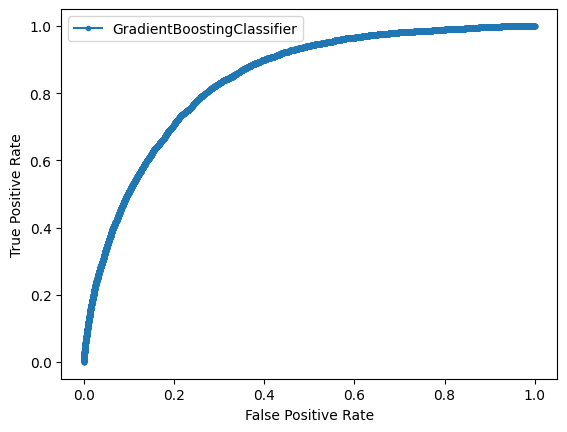

In [34]:
# calculate roc curves
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
%matplotlib inline

probs = pipe.predict_proba(X_test)[:, 1]  # probability for class 1
fpr, tpr, thresholds = roc_curve(y_test, probs)
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.', label=model.__class__.__name__)
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()

## XGBoost

In [82]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric="logloss",
    max_depth=4,
    n_estimators=200,
    learning_rate=0.1
)
test_model(xgb, X_train, X_test, y_train, y_test, threshold=0.19)


XGBClassifier
Confusion Matrix:
TP=2790, FN=2802, FP=6339, TN=52028
Recall = 0.4989270386266094


,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.419878,0.127659,0.966023,0.225516
1,RandomForestClassifier,0.453838,0.134073,0.961195,0.235322
2,DecisionTreeClassifier,0.445457,0.131978,0.957976,0.231995
3,GradientBoostingClassifier,0.855235,0.303673,0.507153,0.379881
4,XGBClassifier,0.857080,0.305619,0.498927,0.379050


In [16]:
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    C=0.1,
    penalty="l2",
    solver="liblinear"
)

# Function to get best threshold

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, precision_score, confusion_matrix

def threshold_sweep(model, X_train, X_test, y_train, y_test, thresholds=None):
    
    if thresholds is None:
        thresholds = np.arange(0.01, 1.0, 0.01)
    
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    probs = pipe.predict_proba(X_test)[:, 1]

    results = []

    for t in thresholds:
        preds = (probs >= t).astype(int)
        
        tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
        
        results.append({
            "Threshold": t,
            "Recall": tp / (tp + fn),
            "Precision": tp / (tp + fp) if (tp+fp)>0 else 0,
            "False Negatives": fn,
            "False Positives": fp,
            "True Positives": tp,
            "True Negatives": tn
        })

    df = pd.DataFrame(results)
    return df

In [18]:
results_df = threshold_sweep(
    log_reg, 
    X_train, X_test, 
    y_train, y_test
)

In [51]:
best = results_df[(results_df["Recall"] >= 0.96)].sort_values("False Positives")
best.head()

,Threshold,Recall,Precision,False Negatives,False Positives,True Positives,True Negatives
18,0.19,0.962983,0.133121,207,35067,5385,23300
17,0.18,0.966202,0.131084,189,35815,5403,22552
16,0.17,0.967990,0.128694,179,36648,5413,21719
15,0.16,0.971745,0.125810,158,37758,5434,20609
14,0.15,0.974249,0.123102,144,38808,5448,19559


# Use Predicted Probability AS the Regression Target

In [ ]:
# ===============================
# 1. Imports
# ===============================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ===============================
# 2. Load your dataset
# ===============================
# Replace with your actual dataset path
data = pd.read_csv("./data/heart_2020_cleaned.csv")


X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

# ===============================
# 3. Train/test split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# 4. Preprocessing
# ===============================
# Identify numeric and categorical features
X_num = X_train.select_dtypes(include='number')
X_cat = X_train.select_dtypes(exclude='number')

# Categorical columns
cat_cols = X_cat.columns

# Numeric columns (all others)
num_cols = X_num.columns

# Numeric pipeline
num_pipe = Pipeline([
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine into preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

# ===============================
# 5. Logistic Regression Classifier
# ===============================
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    C=0.1,
    penalty="l2",
    solver="liblinear"
)

pipe_clf = Pipeline([
    ("prep", preprocessor),
    ("model", log_reg)
])

pipe_clf.fit(X_train, y_train)

# Predicted probabilities (risk scores)
train_probs = pipe_clf.predict_proba(X_train)[:, 1]
test_probs = pipe_clf.predict_proba(X_test)[:, 1]

# ===============================
# 6. Regression Model to Predict Risk Scores
# ===============================
y_train_reg = train_probs
y_test_reg = test_probs

reg_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

pipe_reg = Pipeline([
    ("prep", preprocessor),
    ("reg", reg_model)
])

pipe_reg.fit(X_train, y_train_reg)

# Predict risk scores on test set
risk_pred = pipe_reg.predict(X_test)

# ===============================
# 7. Evaluate Regression
# ===============================
print("MAE:", mean_absolute_error(y_test_reg, risk_pred))
print("R²:", r2_score(y_test_reg, risk_pred))
print("Correlation:", np.corrcoef(y_test_reg, risk_pred)[0,1])

# ===============================
# 8. Convert to Risk Percentage & Category
# ===============================
# Convert probability to percentage
risk_percentage = risk_pred * 100

# Define risk categories
def get_risk_category(prob):
    if prob < 0.2:
        return "Low"
    elif prob < 0.5:
        return "Moderate"
    elif prob < 0.8:
        return "High"
    else:
        return "Very High"

risk_category = [get_risk_category(p) for p in risk_pred]

# Combine into a DataFrame for display
risk_results = pd.DataFrame({
    "Predicted Probability": risk_pred,
    "Risk Percentage": risk_percentage,
    "Risk Category": risk_category
})

# Show first few results
risk_results.head()


MAE: 0.05709478120761218
R²: 0.9043547502405335
Correlation: 0.9510077703242301
   Predicted Probability  Risk Percentage Risk Category
0               0.577631        57.763136          High
1               0.545079        54.507918          High
2               0.101797        10.179681           Low
3               0.818837        81.883745     Very High
4               0.169658        16.965776           Low


In [33]:
risk_results.head(10)

,Predicted Probability,Risk Percentage,Risk Category
0,0.577631,57.763136,High
1,0.545079,54.507918,High
2,0.101797,10.179681,Low
3,0.818837,81.883745,Very High
4,0.169658,16.965776,Low
5,0.513815,51.381452,High
6,0.419885,41.988451,Moderate
7,0.438661,43.866087,Moderate
8,0.130849,13.084892,Low
9,0.096451,9.645107,Low
